# Troubleshoot homomer design and assembly

If structure validation fails, here are suggested steps to take to tune either the CG model or the simulations to generate a successfully validated target assembly.




In [1]:
from itertools import combinations
from pathlib import Path
import json
import numpy as np

from ionerdss.model import pdb
from ionerdss.model.pdb import PDBModelBuilder


## 1. Local NERDSS Executable

This tutorial requires a local NERDSS installation:



In [2]:
import shutil

# The NERDSS executable, or your NERDSS checkout (bin/nerdss inside it is found). It is
# picked up from your PATH if `nerdss` is on it; otherwise replace the placeholder.
nerdss_path = shutil.which('nerdss') or 'PATH_TO_NERDSS_REPO'
print('NERDSS executable found:', Path(nerdss_path).expanduser().exists())

NERDSS executable found: True


## 2. Specify PDB id and output directory for CG and sim files



In [3]:
pdb_id = "8IP3"
prefix_name = f"{pdb_id}_validation_"

# Where the coarse-grained model and the simulation files are written
output_dir = Path('troubleshoot_output')
output_dir.mkdir(parents=True, exist_ok=True)

## 3. List the hyperparameters used for coarse-graining, so it's clear what options we can use to tune the structure

The values below are this notebook's starting point, and the comments give the ioNERDSS defaults. Only the ones passed to `build_system(...)` in the next step take effect.


In [4]:
interface_detect_distance_cutoff=0.6  # default 0.9 nm
interface_detect_n_residue_cutoff = 4  # default 2
min_chain_length = 4

#interface detection
homotypic_detection="auto"
homotypic_detection_interface_radius = 8.0
homotypic_detection_residue_similarity_threshold=0.5  # default 0.7
homodimer_distance_threshold=0.5

#chain grouping and alignment
chain_grouping_seq_threshold=0.5
chain_grouping_matching_mode="default"
chain_grouping_custom_aligner=None

#geometry and regularization
is_on_sphere = False
steric_clash_mode="off"
signature_precision=6
template_regularization_strength=0
#Interface homotypic?
interface_type_assignment_distance_threshold=2.0 #\delta_d
interface_type_assignment_angle_threshold=0.2 #\delta_rad

generate_visualizations=True


## 4. Run the Coarse-graining and input file generation steps

In [5]:
# Use output_dir instead of tempfile
sim_workspace = output_dir / f"{pdb_id}_validation"
sim_workspace.mkdir(exist_ok=True)

builder = PDBModelBuilder(source=pdb_id)
system = builder.build_system(
    workspace_path=str(sim_workspace),   # <-- use your dir here
    interface_detect_distance_cutoff=interface_detect_distance_cutoff,
    interface_detect_n_residue_cutoff=interface_detect_n_residue_cutoff,
    interface_type_assignment_distance_threshold=interface_type_assignment_distance_threshold,
    interface_type_assignment_angle_threshold=interface_type_assignment_angle_threshold,
    generate_visualizations=generate_visualizations,
)

2026-10-01 16:46:34 - ionerdss.pdb.8IP3 - WARNING - WARNING: small sigma values : 0.359193; consider increasing binding radius threshold


## 5. Report the number of chains found and the number of interfaces detected


In [6]:
#Return basic information about the CG model that was built, so the user can check if it matches their expectations.
#print(builder)
print(system)
print(f"Number of chains found N_chain: {len(system.molecule_instances)}")
print(f"Number of distinct subunits found N_mol: {len(system.molecule_types)}")
print(f"Number of total interfaces detected N_interface: {len(system.interface_instances)}")
print(f"Number of unique interfaces detected N_interface_unique: {len(system.interface_types)}")

System(pdb_id=8IP3, molecule_types=1, molecule_instances=5, interface_types=2, interface_instances=10)
Number of chains found N_chain: 5
Number of distinct subunits found N_mol: 1
Number of total interfaces detected N_interface: 10
Number of unique interfaces detected N_interface_unique: 2


## 5a. Inspect designed CG coordinates and interface assignments

In [7]:
def summarize_designed_structure(system):
    designed_structure = pdb.validation.get_designed_structure(system)
    print('Designed assembly records:')
    for instance_name, record in designed_structure.items():
        com = tuple(round(value, 3) for value in record['global_com_coord'])
        print(f"  {instance_name}: type={record['type']}, COM={com}")
        for interface in record['interfaces']:
            interface_coord = tuple(round(value, 3) for value in interface['global_interface_coord'])
            print(
                "    -> "
                f"interface={interface['interface_instance']} "
                f"type={interface['interface_type']} "
                f"partner={interface['binding_partner_instance']} "
                f"({interface['binding_partner_type']}), coord={interface_coord}"
            )
        if not record['interfaces']:
            print('    -> no bound interfaces recorded')


def report_bound_distances(system):
    seen_pairs = set()
    rows = []
    for molecule_instance in system.molecule_instances:
        for interface, partner in molecule_instance.interfaces_neighbors_map.items():
            pair = tuple(sorted((molecule_instance.name, partner.name)))
            if pair in seen_pairs:
                continue
            seen_pairs.add(pair)
            distance = float(np.linalg.norm(molecule_instance.com - partner.com))
            rows.append((pair[0], pair[1], interface.get_name(), round(distance, 3)))

    print('Bound partner COM-COM distances (nm):')
    for left, right, interface_name, distance in sorted(rows):
        print(f"  {left} <-> {right} via {interface_name}: {distance}")

    if len(system.molecule_instances) > 1:
        all_distances = []
        for first, second in combinations(system.molecule_instances, 2):
            distance = float(np.linalg.norm(first.com - second.com))
            all_distances.append((first.name, second.name, round(distance, 3)))

        shortest = min(all_distances, key=lambda row: row[2])
        print('\nShortest COM-COM distance in the assembly:')
        print(f"  {shortest[0]} <-> {shortest[1]}: {shortest[2]} nm")


# Report the full designed coarse-grained assembly coordinates and interface identities.
summarize_designed_structure(system)


Designed assembly records:
  A_A: type=A, COM=(12.602, 13.845, 10.72)
    -> interface=A_A_B_A_1 type=AA1f partner=B_A (A), coord=(12.837, 11.863, 15.849)
    -> interface=A_A_E_A_1 type=AA1b partner=E_A (A), coord=(12.407, 11.498, 15.806)
  B_A: type=A, COM=(10.578, 13.119, 10.72)
    -> interface=B_A_A_A_1 type=AA1b partner=A_A (A), coord=(12.75, 12.209, 15.806)
    -> interface=B_A_C_A_1 type=AA1f partner=C_A (A), coord=(12.536, 12.73, 15.849)
  C_A: type=A, COM=(10.645, 10.971, 10.72)
    -> interface=C_A_B_A_1 type=AA1b partner=B_A (A), coord=(12.182, 12.755, 15.806)
    -> interface=C_A_D_A_1 type=AA1f partner=D_A (A), coord=(11.619, 12.713, 15.849)
  D_A: type=A, COM=(12.708, 10.37, 10.72)
    -> interface=D_A_C_A_1 type=AA1b partner=C_A (A), coord=(11.486, 12.383, 15.806)
    -> interface=D_A_E_A_1 type=AA1f partner=E_A (A), coord=(11.352, 11.835, 15.849)
  E_A: type=A, COM=(13.917, 12.145, 10.72)
    -> interface=E_A_A_A_1 type=AA1f partner=A_A (A), coord=(12.105, 11.308, 15.8

In [8]:
# Full report
pdb.validation.get_designed_structure(system)

{'A_A': {'instance': 'A_A',
  'type': 'A',
  'global_com_coord': (12.601520538330078,
   13.84512939453125,
   10.720112609863282),
  'interfaces': [{'interface_instance': 'A_A_B_A_1',
    'interface_type': 'AA1f',
    'binding_partner_instance': 'B_A',
    'binding_partner_type': 'A',
    'global_interface_coord': (12.837307929992676,
     11.862665176391602,
     15.848976135253906)},
   {'interface_instance': 'A_A_E_A_1',
    'interface_type': 'AA1b',
    'binding_partner_instance': 'E_A',
    'binding_partner_type': 'A',
    'global_interface_coord': (12.406908988952637,
     11.49839973449707,
     15.806063652038574)}]},
 'B_A': {'instance': 'B_A',
  'type': 'A',
  'global_com_coord': (10.578067779541016,
   13.118724060058593,
   10.720111083984374),
  'interfaces': [{'interface_instance': 'B_A_A_A_1',
    'interface_type': 'AA1b',
    'binding_partner_instance': 'A_A',
    'binding_partner_type': 'A',
    'global_interface_coord': (12.749773025512695,
     12.208517074584961,
 

## DEBUGGING STRATEGIES FOR THE CG MODEL:

In [9]:
# If there are too few interfaces, and some subunits are not connected to the rest of the complex
# then we can try to relax the interface detection parameters and see if we can get more interfaces that connect the complex together.
interface_detect_distance_cutoff=1.0
interface_detect_n_residue_cutoff = 3

# Now rerun the CG model building with the relaxed parameters, and see if we can get more interfaces that connect the complex together.

builder = PDBModelBuilder(source=pdb_id)
system = builder.build_system(
    workspace_path=str(sim_workspace), 
    interface_detect_distance_cutoff=interface_detect_distance_cutoff,
    interface_detect_n_residue_cutoff = interface_detect_n_residue_cutoff,
    interface_type_assignment_distance_threshold=interface_type_assignment_distance_threshold,
    interface_type_assignment_angle_threshold=interface_type_assignment_angle_threshold,
    generate_visualizations=False,
    generate_nerdss_files=False,
)

#And report the statistics of the new model.


2026-10-01 16:46:35 - ionerdss.pdb.8IP3 - WARNING - Skipping interface type AA1 for B<->C because the concrete assignment AA1/AA1 is already present.


2026-10-01 16:46:35 - ionerdss.pdb.8IP3 - WARNING - Skipping interface type AA1 for D<->E because the concrete assignment AA1/AA1 is already present.


In [10]:
#report statistics of the new model
print(f"Number of chains found N_chain: {len(system.molecule_instances)}")
print(f"Number of distinct subunits found N_mol: {len(system.molecule_types)}")
print(f"Number of total interfaces detected N_interface: {len(system.interface_instances)}")
print(f"Number of unique interfaces detected N_interface_unique: {len(system.interface_types)}")


Number of chains found N_chain: 5
Number of distinct subunits found N_mol: 1
Number of total interfaces detected N_interface: 10
Number of unique interfaces detected N_interface_unique: 3


In [11]:
# Report coordinates of the rebuilt model after relaxing interface detection.
summarize_designed_structure(system)


Designed assembly records:
  A_A: type=A, COM=(12.602, 13.845, 10.72)
    -> interface=A_A_B_A_1 type=AA1 partner=B_A (A), coord=(12.523, 12.438, 13.88)
    -> interface=A_A_E_A_2 type=AA2 partner=E_A (A), coord=(12.908, 12.239, 13.339)
  B_A: type=A, COM=(10.578, 13.119, 10.72)
    -> interface=B_A_A_A_1 type=AA1 partner=A_A (A), coord=(12.201, 12.914, 13.339)
    -> interface=B_A_C_A_3 type=AA3 partner=C_A (A), coord=(11.892, 12.609, 13.88)
  C_A: type=A, COM=(10.645, 10.971, 10.72)
    -> interface=C_A_B_A_3 type=AA3 partner=B_A (A), coord=(11.341, 12.45, 13.339)
    -> interface=C_A_D_A_1 type=AA1 partner=D_A (A), coord=(11.538, 12.056, 13.89)
  D_A: type=A, COM=(12.708, 10.37, 10.72)
    -> interface=D_A_C_A_1 type=AA1 partner=C_A (A), coord=(11.516, 11.489, 13.339)
    -> interface=D_A_E_A_3 type=AA3 partner=E_A (A), coord=(11.952, 11.555, 13.89)
  E_A: type=A, COM=(13.917, 12.145, 10.72)
    -> interface=E_A_A_A_2 type=AA2 partner=A_A (A), coord=(12.555, 11.785, 13.88)
    -> in

In [12]:
# Print out COM-COM distances for bound partners and the shortest pair in the assembly.
report_bound_distances(system)


Bound partner COM-COM distances (nm):
  A_A <-> B_A via A_A_B_A_1: 2.15
  A_A <-> E_A via A_A_E_A_2: 2.15
  B_A <-> C_A via B_A_C_A_3: 2.149
  C_A <-> D_A via C_A_D_A_1: 2.149
  D_A <-> E_A via D_A_E_A_3: 2.148

Shortest COM-COM distance in the assembly:
  D_A <-> E_A: 2.148 nm


## If the homomer keeps assembling well past its target size (a 5-mer is reporting a 12-mer, for example)

This is more likely to indicate that too many interfaces are present.
1. Try making interface detection constrains tighter
2. Try increasing overlapSepLimit, if simulations might be allowing multiple imperfectly aligned subunits to add


In [13]:
interface_detect_distance_cutoff=0.6  # no trailing comma here, or Python makes it a tuple
interface_detect_n_residue_cutoff = 4

#its possible it is not properly detecting that an interface is the same on both proteins, so relax those constraints?
#Interface homotypic?
interface_type_assignment_distance_threshold=3.0 #\delta_d
interface_type_assignment_angle_threshold=0.3 #\delta_rad

# Now rerun the CG model building with the relaxed parameters, and see if we can get more interfaces that connect the complex together.

builder = PDBModelBuilder(source=pdb_id)
system = builder.build_system(
    workspace_path=str(sim_workspace), 
    interface_detect_distance_cutoff=interface_detect_distance_cutoff,
    interface_detect_n_residue_cutoff = interface_detect_n_residue_cutoff,
    interface_type_assignment_distance_threshold=interface_type_assignment_distance_threshold,
    interface_type_assignment_angle_threshold=interface_type_assignment_angle_threshold,
    generate_visualizations=False,
    generate_nerdss_files=False,
)

#And report the statistics of the new model.

## 6. NERDSS simulation parameters for the validation run

In [14]:
nerdss_total_molecule_count=100
nerdss_water_box=(100,100,100)
nerdss_time_step=0.1
nerdss_n_itr=100000
default_on_rate_3d_ka=120
# no off-rate to set: setup_simulation makes every validation binding reaction irreversible
pdbWrite = 100 #save structures often for easier visualization
timeWrite = 100 #save time series data often for easier tracking of growth.

#RestartWrite must be LESS THAN total iterations, so these files get written!

restartWrite = 20000.0 #save restart files often so we can restart from different points in the trajectory if we want to test different parameters.
if(restartWrite >= nerdss_n_itr):
    raise ValueError("restartWrite must be less than total iterations (nerdss_n_itr) to ensure restart files get written!")

checkPoint= 10000.0
trajWrite = 20000.0
#checkPoint should be more frequent than restart (or equal to it, otherwise restart files won't get writte)
if(checkPoint > restartWrite):
    raise ValueError("checkPoint should be more or equally frequent than restartWrite to ensure restart files get written!")
    #checkPoint = restartWrite. <--- do this


#the titration rate can be sped up to get more copies into the volume over the simulation time.
titration_on_rate=5e-2 # M/s, zeroth-order creation rate of each molecule type. Lower it to add copies more slowly.

#overlapSepLimit is a distance threshold in nm that is only evaluated after a subunit associates with another subunit. (they have to be flagged for this whcih is the default)
#it is evaluated between all subunits within the two associating complexes, not just the two subunits that are literally associating, since they may be part of large complexes.
#the maximum value for overlapSepLimit is the shortest COM-COM distance between two bound molecules in the system.
#if it exceeds this value, those otherwise correct binding events will be rejected due to steric clashes. So, it should be set to a value smaller than the shortest COM-COM distance between two bound molecules in the system.
overlapSepLimit = 0.5 # in nm: how close can two bound molecules get within a complex before we consider it a steric clash and reject the move


## 7. Set-up the NERDSS validation simulation, single copies + titration

We use a moderately small box and a longer run.
Use only one copy of each subunit.
Perform titration of additional subunits, to provide more copies to assemble. This titration is essential for homomers.


In [15]:
import shutil

sim_workspace = output_dir / f"{pdb_id}_validation"

# Clear and recreate fresh each time by uncommenting code below
#if sim_workspace.exists():
#    shutil.rmtree(sim_workspace)
#sim_workspace.mkdir(parents=True)

artifacts = pdb.validation.setup_simulation(
    system,
    workspace_manager=builder.workspace_manager,
    box_nm=nerdss_water_box,
    initial_molecule_count=1,
    titration_on_rate=titration_on_rate,
    parms_overrides={
        'nItr': nerdss_n_itr,
        'timeWrite': timeWrite,
        'timeStep': nerdss_time_step,
        'trajWrite': trajWrite,
        'restartWrite': restartWrite,
        'checkPoint': checkPoint,
        'pdbWrite': pdbWrite, 
        'overlapSepLimit': overlapSepLimit,
    },
)

with open(artifacts.target_file, 'r', encoding='utf-8') as handle:
    target_payload = json.load(handle)

print('Validation workspace:', builder.workspace_manager.workspace_path)
print('Validation counts:', artifacts.molecule_counts)
print('Target file:', artifacts.target_file)
print('parms.inp:', artifacts.nerdss_files['parms'])
print('parms_titrate.inp:', artifacts.nerdss_files['parms_titrate'])
print('Target payload keys:', target_payload.keys())



2026-10-01 16:46:35 - ionerdss.pdb.8IP3 - WARNING - WARNING: small sigma values : 0.359193; consider increasing binding radius threshold


Validation workspace: troubleshoot_output/8IP3_validation
Validation counts: {'A': 5}
Target file: troubleshoot_output/8IP3_validation/structure_validation/structure_validation_target.json
parms.inp: troubleshoot_output/8IP3_validation/structure_validation/parms.inp
parms_titrate.inp: troubleshoot_output/8IP3_validation/structure_validation/parms_titrate.inp
Target payload keys: dict_keys(['molecule_counts', 'designed_coordinates'])


## 8. Run the Actual NERDSS Validation Simulation

This is the key validation step: the observed structure is taken from a real NERDSS run, not from a synthetic rigid transform.

If no full assembly matching the designed one-copy target appears in the histogram, the validation suite returns a warning and does not attempt alignment.


In [16]:


simulation_error = None
try:
    sim_result = pdb.validation.run_simulation(
        artifacts,
        nerdss_path=nerdss_path,
    )
except ValueError as exc:
    sim_result = None
    simulation_error = exc
    print(exc)


Working directory set to: troubleshoot_output/8IP3_validation/structure_validation


ionerdss/model/pdb/structure_validation.py:1678: RuntimeWarning: Multiple full assemblies matching the validation target were present in the COMPLEXES snapshot 99999.json; selecting the first matching complex.
  warnings.warn(


In [17]:
# now check the validation results and report on the growth of the complex, and whether it matches the expected behavior based on the CG model that was built.

In [18]:


if sim_result is None:
    print('Simulation failed before a validation result was returned:')
    print(simulation_error)
else:
    print('Simulation dir:', sim_result.simulation_dir)
    print('Histogram file:', sim_result.histogram_file)
    print('Full assembly found:', sim_result.full_assembly_found)
    print('First full assembly time:', sim_result.first_full_assembly_time)
    if sim_result.warning_message:
        print(sim_result.warning_message)
    else:
        print('Observed coordinates:', sim_result.observed_coordinates)


Simulation dir: troubleshoot_output/8IP3_validation/structure_validation/validation_output/1
Histogram file: troubleshoot_output/8IP3_validation/structure_validation/validation_output/1/DATA/histogram_complexes_time.dat
Full assembly found: True
First full assembly time: 0.00086
Observed coordinates: {'A_0': (26.127383684181652, 96.47689962881499, 14.300248285840418), 'A_1': (26.109369143192076, 95.02819302816934, 12.712978035567922), 'A_2': (24.86550237957395, 95.78851878244367, 11.133990256136741), 'A_3': (24.114752367843767, 97.70712766454037, 11.745395656236411), 'A_4': (24.894618220800666, 98.13256424557662, 13.702259257194015)}


{'A_0': (26.127383684181652, 96.47689962881499, 14.300248285840418), 'A_1': (26.109369143192076, 95.02819302816934, 12.712978035567922), 'A_2': (24.86550237957395, 95.78851878244367, 11.133990256136741), 'A_3': (24.114752367843767, 97.70712766454037, 11.745395656236411), 'A_4': (24.894618220800666, 98.13256424557662, 13.702259257194015)}


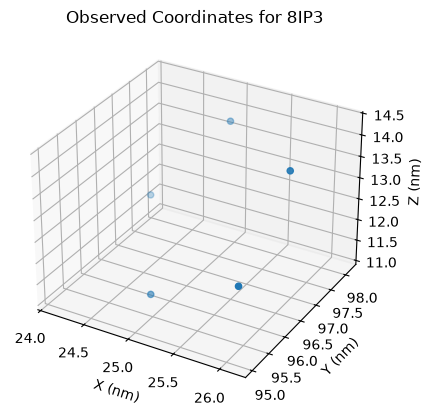

In [19]:
# Plot the observed coordinates when a full assembly was successfully extracted.
import matplotlib.pyplot as plt
if sim_result is None or sim_result.observed_coordinates is None:
    print('No observed coordinates to plot.')
else:
    print(sim_result.observed_coordinates)
    coords = np.array(list(sim_result.observed_coordinates.values()), dtype=float)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2])
    ax.set_title(f'Observed Coordinates for {pdb_id}')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    plt.show()



## DEBUGGING STRATEGIES--IF A FULL ASSEMBLY IS NOT FOUND:

If a full assembly is not found, try running the simulation for longer. 
For heteromers, you can also slow down titration if it is adding too many copies too quickly, leading to kinetic traps.
If you speed up titration, it will add more monomers of all types more quickly to the volume.
You can also increase the system volume if it is getting too crowded for a very large assembly. 

In [20]:
nerdss_water_box=(100,100,100)
nerdss_time_step=0.2
nerdss_n_itr=500000
default_on_rate_3d_ka=120
pdbWrite = 100 #save structures often for easier visualization
timeWrite = 100 #save time series data often for easier tracking of growth.

#the titration rate can be sped up to get more copies into the volume over the simulation time.
titration_on_rate=5e-4 # M/s: 100x slower titration than above, to give each assembly time to complete


## Re-set-up the NERDSS simulation with the new parameters, then rerun step 8.

In [21]:
artifacts = pdb.validation.setup_simulation(
    system,
    workspace_manager=builder.workspace_manager,
    box_nm=nerdss_water_box,
    initial_molecule_count=1,
    titration_on_rate=titration_on_rate,
    parms_overrides={
        'nItr': nerdss_n_itr,
        'timeWrite': timeWrite,
        'timeStep': nerdss_time_step,
        'trajWrite': trajWrite,
        'restartWrite': restartWrite,
        'checkPoint': checkPoint,
        'pdbWrite': pdbWrite,
        'overlapSepLimit': overlapSepLimit,
    },
)

2026-10-01 16:46:43 - ionerdss.pdb.8IP3 - WARNING - WARNING: small sigma values : 0.359193; consider increasing binding radius threshold


## 9. VALIDATE: Align the Observed NERDSS Structure Back to the Design

Only perform alignment when the real NERDSS run actually produced at least one full assembly.


In [ ]:
if sim_result is not None and sim_result.full_assembly_found and sim_result.observed_coordinates is not None:
    alignment = pdb.validation.align_structure(
        artifacts.designed_coordinates,
        sim_result.observed_coordinates,
        backend='kabsch',
    )
    print('Observed RMSD:', alignment.rmsd)
    if alignment.rmsd < 0.1:
        print('The observed structure is in strong agreement (<0.1 nm) with the designed structure.')
    elif alignment.rmsd < 1.0:
        print('The observed structure is in <some> agreement (0.1<RMSD<1.0 nm) with the designed structure.')
    elif alignment.rmsd >= 1.0:
        print('The observed structure has problematic alignment with the designed structure. Consider adjusting the simulation parameters or checking for errors in the model.')
else:
    print('Skipping alignment because no full assembly coordinates were returned from the NERDSS validation run.')



Observed RMSD: 0.0005038094393485262


## More troubleshooting
If it can find a completed assembly, the RMSD should be nice and low.
If not, there may be too many interfaces.
For homomers, there can be other issues: if imperfectly aligned subunits keep adding to a ring, try increasing `overlapSepLimit` (step 6), keeping it below the shortest bound COM-COM distance reported in step 5a.

In [ ]:
#print out the aligned coordinates of the observed structure and the designed structure for comparison.
#only the COM coordinates are included.
print('Aligned observed COM coordinates (nm):')
print(alignment.aligned_observed_coordinates)
print('Designed COM coordinates (nm):')
print(designed_coords)

In [ ]:
# Now we can plot the designed structure and the observed structure together to visualize how well they align.
if sim_result.full_assembly_found:
    aligned_observed_coords = np.array(list(alignment.aligned_observed_coordinates), dtype=float)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(designed_coords[:, 0], designed_coords[:, 1], designed_coords[:, 2], label='Designed', color='blue', marker='o')
    ax.scatter(aligned_observed_coords[:, 0], aligned_observed_coords[:, 1], aligned_observed_coords[:, 2], label='Observed', color='red',marker='*')
    ax.set_title(f'Aligned COM Coordinates for {pdb_id}')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.grid(True)
    #change the z limits to make the agreement more visible.
    z_min = min(np.min(designed_coords[:, 2]), np.min(aligned_observed_coords[:, 2]))
    z_max = max(np.max(designed_coords[:, 2]), np.max(aligned_observed_coords[:, 2]))
    z_range = 2
    ax.set_zlim(z_min - z_range, z_max + z_range)   
    ax.legend()
    plt.show()

## Check to see if there is Over-Assembly, that is, if it has formed assemblies that exceed the size of the target.

In [ ]:
# look in the histogram_file to see if there are assemblies that contain more subunits than the full assembly
#so we need to know how many subunits are in the designed_target_structure
num_chains_target = len(designed_structure)
print(f"Number of chains in the designed structure: {num_chains_target}")

#Look in the histogram file to see if there are assemblies that contain more subunits than the full assembly.
#histogram_complexes_time.dat is NERDSS's native format, not JSON, so we use the built-in parser instead of json.loads.
from ionerdss.analysis.io.parser import parse_complex_histogram

if sim_result.histogram_file is not None:
    hist_times, hist_comps, hist_matrix = parse_complex_histogram(Path(sim_result.histogram_file))
    print(f"Parsed {len(hist_times)} time points and {len(hist_comps)} distinct complex compositions.")
    safe = True
    for comp in hist_comps:
        num_chains_in_assembly = sum(comp.values())
        if num_chains_in_assembly > num_chains_target:
            safe=False
            print("-OVER ASSEMBLY FOUND---")
            print(f"Warning: Found an assembly with composition {comp} ({num_chains_in_assembly} chains), which exceeds the designed structure's {num_chains_target} chains.")

    if(safe):
        print("Good: No over-assembly found!")

## 10. Plot the designed structure including interfaces, with alignment

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_coarse_grained_structure_inline(coarse_grainer, figsize=(12, 10)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    chains = coarse_grainer.get_coarse_grained_chains()
    interfaces = coarse_grainer.get_interfaces()

    coms, chain_ids = [], []
    for chain_id, chain_data in chains.items():
        coms.append(chain_data.com / 10.0)  # angstrom -> nm
        chain_ids.append(chain_id)

    if coms:
        coms = np.array(coms)
        ax.scatter(coms[:, 0], coms[:, 1], coms[:, 2], c='red', s=200, alpha=0.8, label='Chain COMs')
        for i, chain_id in enumerate(chain_ids):
            ax.text(coms[i, 0], coms[i, 1], coms[i, 2], f'  {chain_id}', fontsize=10, fontweight='bold')

    interface_coords = []
    for interface in interfaces:
        interface_coords.extend([interface.coord_i / 10.0, interface.coord_j / 10.0])
    if interface_coords:
        interface_coords = np.array(interface_coords)
        ax.scatter(interface_coords[:, 0], interface_coords[:, 1], interface_coords[:, 2],
                   c='blue', s=50, alpha=0.7, label='Interfaces')

    for interface in interfaces:
        com_i_nm = chains[interface.chain_i].com / 10.0
        com_j_nm = chains[interface.chain_j].com / 10.0
        intf_i_nm = interface.coord_i / 10.0
        intf_j_nm = interface.coord_j / 10.0
        ax.plot(*zip(com_i_nm, intf_i_nm), 'gray', alpha=0.5, linewidth=1)
        ax.plot(*zip(com_j_nm, intf_j_nm), 'gray', alpha=0.5, linewidth=1)

    ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)'); ax.set_zlabel('Z (nm)')
    ax.set_title('Designed Coarse-Grained Structure')
    ax.legend()
    plt.show()
    return fig, ax

# usage:
plot_coarse_grained_structure_inline(builder.system_builder.coarse_grainer)